In [1]:
# Initialization

import os

use_gdrive, use_git, use_local = False, True, False

use_colab = 'COLAB_GPU' in os.environ

if use_gdrive:
  from google.colab import drive
  drive.mount('/content/drive')
  # Change with your drive "media" folder
  !ln -s "/content/drive/MyDrive/MyTeaching/Elaborazione-Audio-Digitale/EAD26_docente/EAD-U04.analisi-audio-frequenza/media" media
if use_git:
  if use_colab:
    !git clone "https://github.com/polito-EAD-2026/EAD26-U04.analisi-audio-frequenza.git"
    !mv ./EAD26-U04.analisi-audio-frequenza/* .
  else:
    import subprocess
    subprocess.run(['git', 'clone', "https://github.com/polito-EAD-2026/EAD26-U04.analisi-audio-frequenza.git"])
    subprocess.run(['mv', './EAD26-U04.analisi-audio-frequenza/*', '.'])

Mounted at /content/drive


# Riferimenti

* [SCIPY] "Spectral Analysis"
  * https://docs.scipy.org/doc/scipy/tutorial/signal.html#tutorial-spectralanalysis
  
* [LERCH] Lerch, "An Introduction to Audio Content Analysis"
  * Ch.3.5 "Instantaneous Features"
    * Spectral Centroid, Spectral Spread, Spectral Rolloff, Zero Crossing Rate, …
  * Code: https://github.com/alexanderlerch/pyACA

* [MULLER] Muller, "Fundamentals of Music Processing"
  * Ch.2 Fourier Analysis of Signals
  * Code: https://audiolabs-erlangen.de/resources/MIR/FMP/C0/C0.html

* [PRAAT] Praat Software - praat.org
  * Weenink, "Speech Signal Processing with Praat"
  * https://www.fon.hum.uva.nl/david/sspbook/sspbook.pdf




In [2]:
# Install Librosa
!pip install -q librosa praat-parselmouth sox
!pip install -q ipympl mpl_interactions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.8/515.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.6 MB/s eta 0:00:00


In [3]:
import librosa
import librosa.display
import numpy as np
import scipy.signal as signal
import parselmouth

import matplotlib
import matplotlib.pyplot as plt


import IPython
import IPython.display as ipd

import ipywidgets as widgets
import mpl_interactions.ipyplot as iplt

# warning: restart session after pip install ipympl
# %matplotlib widget
%matplotlib inline

from google.colab import output
output.enable_custom_widget_manager()

matplotlib.rcParams.update({'font.size': 14})

import IPython
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from pprint import pprint

import scipy
from scipy import signal

In [4]:
def gen_cos(dur=1, Fs=100, amp=1, freq=2, phase=0):
    num_samples = int(Fs * dur)
    t = np.arange(num_samples) / Fs
    x = amp * np.cos( (2*np.pi*freq*t) + phase)
    return x, t

def dft(x, Fs, N=None):
  L = len(x)
  N = L if N is None else N
  X = np.fft.rfft(x, N)
  X_ = np.abs(X) / (L/2)
  freq = np.fft.rfftfreq(N, d=1./Fs)
  # X_ = X_[:N//2+1]
  # freq = freq[:N//2+1]
  X_dBFS = 20*np.log10(X_)
  return X_dBFS, freq

def RMS(x):
  return np.sqrt(np.mean(x**2))

def dBFS(x):
  return 20*np.log10(RMS(x))

def plot_vs_time(w, t, xlim=None, ylim=[-1, +1], fig=None, fmt='-'):
  fig, ax = plt.subplots(figsize=(12,3)) if fig is None else fig
  ax.plot(t,w,fmt)
  ax.set_xlabel('Time (s)')
  ax.set_ylabel('Amplitude')
  ax.set_xlim(xlim) if xlim is not None else plt.xlim(t[0],t[-1])
  ax.set_ylim(ylim) if ylim is not None else None
  fig.tight_layout()
  ax.grid(visible=True)
  # plt.show()

# plot frequency spectrum
def plot_vs_freq(X, f, Fs, xlim=None, ylim=None, fig=None, zp=False, fmt='-'):
  xlim = [np.min(f), np.max(f)] if xlim is None else xlim
  ylim = [-60, +6] if ylim is None else ylim
  fig, ax = plt.subplots(figsize=(12,3)) if fig is None else fig
  ax.plot(f, X, fmt)
  ax.set_xlabel('Frequency (Hz)')
  ax.set_ylabel('Magnitude (dBFS)') # Modulo
  ax.set_xlim(xlim)
  ax.set_ylim(ylim)
  plt.grid(visible=True);
  plt.tight_layout()


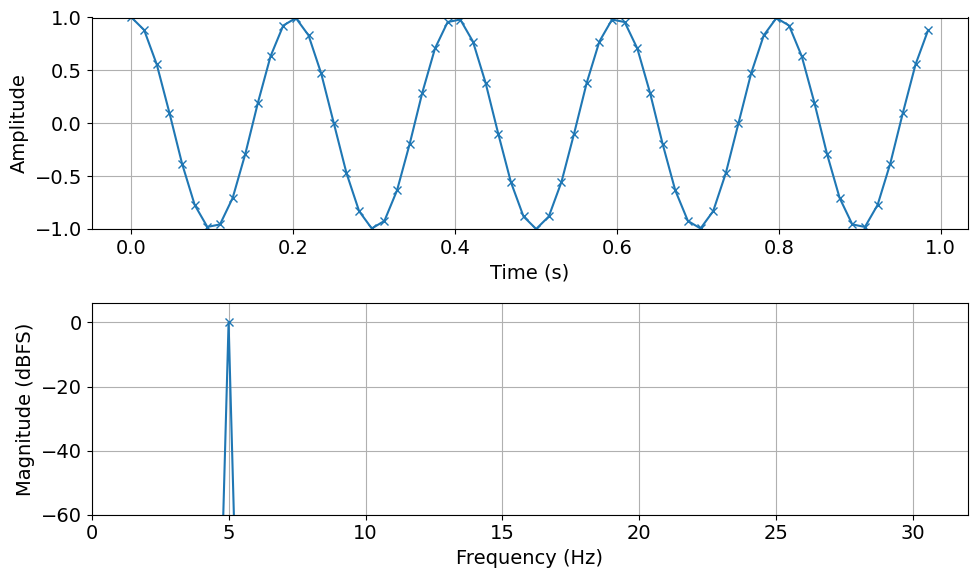

In [5]:
Fs = 64
fig, [ax1, ax2] = plt.subplots(2,1, figsize=(10,6))
x, t = gen_cos(amp=1, freq=5, Fs=Fs, dur=1) # try also with dur = 1.1
plot_vs_time(x, t, fmt='-x', fig=(fig,ax1))
X, f = dft(x, Fs)
plot_vs_freq(X, f, Fs, fmt='-x', fig=(fig,ax2))

plt.savefig('plot.png', transparent=True)

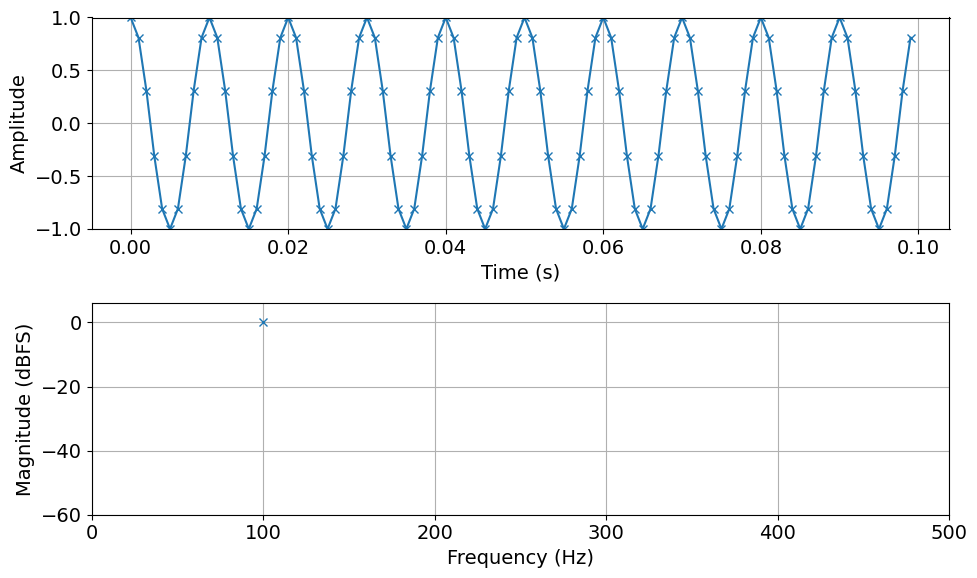

In [6]:
Fs = 1000
f = 100
dur = 1/10 # try also 1/7 1/6
fig, [ax1, ax2] = plt.subplots(2,1, figsize=(10,6))
x, t = gen_cos(amp=1, freq=f, Fs=Fs, dur=dur)

# w = scipy.signal.get_window('hann', len(x))
# x = x * w

plot_vs_time(x, t, fmt='-x', fig=(fig,ax1))
X, f = dft(x, Fs)
plot_vs_freq(X, f, Fs, fmt='x', fig=(fig,ax2))


xp = np.tile(x,8)
samps = int(  (len(xp) ) * 8000 / Fs ) # the frequency f remains the same
signal = scipy.signal.resample(xp, samps)
ipd.display(ipd.Audio(signal, rate=8000))

import soundfile as sf
sf.write('resampled.wav', xp, 8000)


# As shown in Fig. 6.10, the elimination of discontinuities does change the signal: we have also introduced a low-frequency amplitude modulation to the looped signal.
# In this example, we have traded off transient discontinuities for a smoothly varying pulse, which can be more easily modeled by sinusoids.

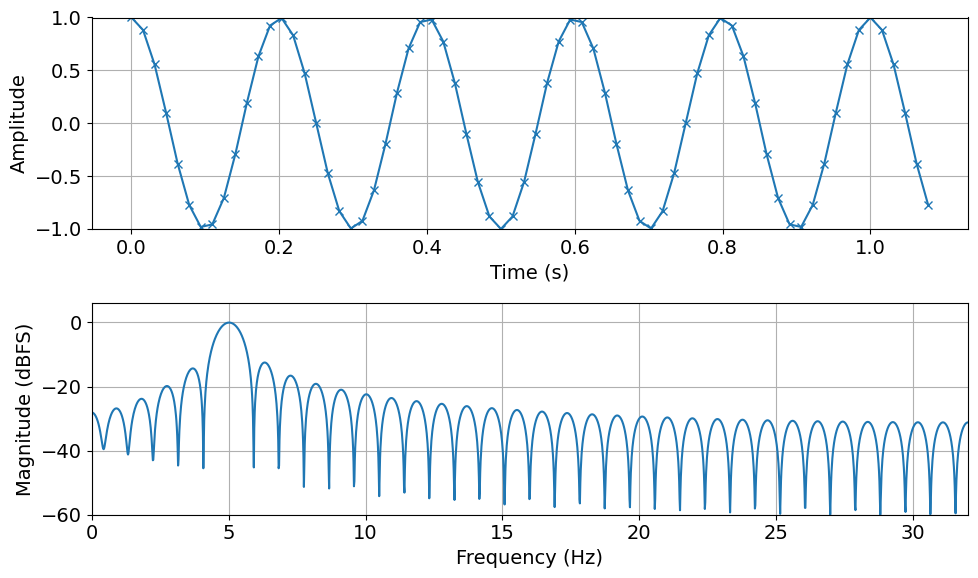

In [7]:
Fs = 64
fig, [ax1, ax2] = plt.subplots(2,1, figsize=(10,6))
x, t = gen_cos(amp=1, freq=5, Fs=Fs, dur=1.1)
plot_vs_time(x, t, fmt='-x', fig=(fig,ax1))
X, f = dft(x, Fs, N=4096)
plot_vs_freq(X, f, Fs, fmt='-', fig=(fig,ax2))

Main lobe width: 2.0 bin
Side lobe height: -13.301 dB


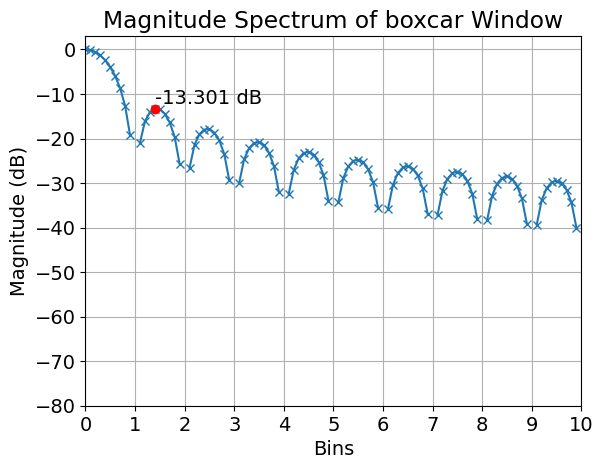

In [8]:
# Teacher reference https://colab.research.google.com/drive/1tkt4YMoeGrHz-p3L6DkE30jw0U_F7pU6#scrollTo=HmWDjWFiLKa3

# COMPUTE WINDOW FUNCTION FOURIER TRANSFORM
# AND THEIR LOBE WIDTH AND HEIGHT

import numpy as np
np.seterr(divide = 'ignore')

import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq, fft, fftshift, fftfreq
from scipy.signal import get_window, find_peaks

# Parameters
N = 256  # Number of points in the window
k = 10


# Generate window
window_name = "boxcar"
# window_name = "hann"
window = get_window(window_name, N)


# Compute Fourier transform
fft_window = rfft(window, n=k*N)  # Zero-padding to improve frequency resolution
fft_magnitude = np.abs(fft_window)  # Center the FFT around zero
# freqs = rfftfreq(k*N, d=k)  # Frequency axis
nfreqs = np.arange(len(fft_magnitude))/k # Bin axis

# Normalize magnitude for easier interpretation
fft_magnitude /= np.max(fft_magnitude)

# Plot the Fourier transform (magnitude spectrum) of the Hanning window

plt.ylim([-80,3])
#plt.ylim([0, 1])
plt.plot(nfreqs, 20 * np.log10(fft_magnitude), '-x')
plt.title(f"Magnitude Spectrum of {window_name} Window")
plt.xlabel(f"Bins")
plt.ylabel("Magnitude (dB)")
plt.xticks(np.arange(0, N))
plt.xlim([0, 10])
plt.grid()

zeropos = np.where(np.isclose(fft_magnitude,np.zeros_like(fft_magnitude)))[0]
n = zeropos[0]
# x,y = freqs[n], -50
# plt.plot(x, y, 'ro')
# plt.annotate(f"{y:.3f} dB", (x, y))
print(f"Main lobe width: {2*n/k} bin")

peaks, _ = find_peaks(20 * np.log10(fft_magnitude[zeropos[0]:]))  # Detect peaks after main lobe
n = zeropos[0]+peaks[0]
x, y = nfreqs[n], 20 * np.log10(fft_magnitude[n])
plt.plot(x, y, 'ro')
plt.annotate(f"{y:.3f} dB", (x, y + 1))
print(f"Side lobe height: {y:.3f} dB")


plt.savefig('plot.png', transparent=True)


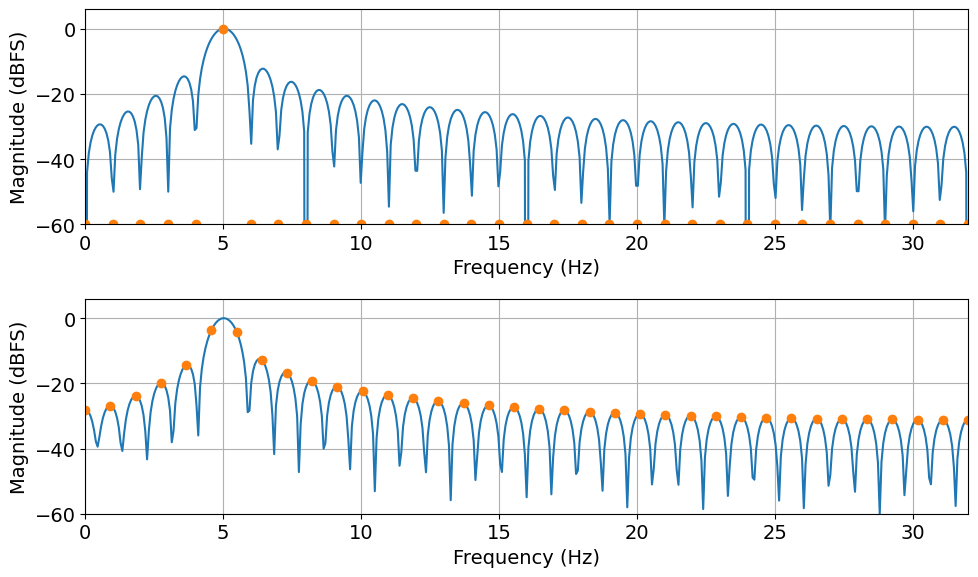

In [9]:
Fs = 64
f0 = 5
A = 1

fig, [ax1, ax2] = plt.subplots(2,1, figsize=(10,6))

x, t = gen_cos(amp=A, freq=f0, Fs=Fs, dur=1)
X, f = dft(x, Fs, 1000)
plot_vs_freq(X, f, Fs, fmt='-', fig=(fig,ax1))
X, f = dft(x, Fs)
n = X < -60
X[n] = -60
ax1.plot(f,X,'o')
ax1.grid()

x, t = gen_cos(amp=A, freq=f0, Fs=Fs, dur=1.1)
X, f = dft(x, Fs, 1000)
plot_vs_freq(X, f, Fs, fmt='-', fig=(fig,ax2))
X, f = dft(x, Fs)
ax2.plot(f,X,'o')

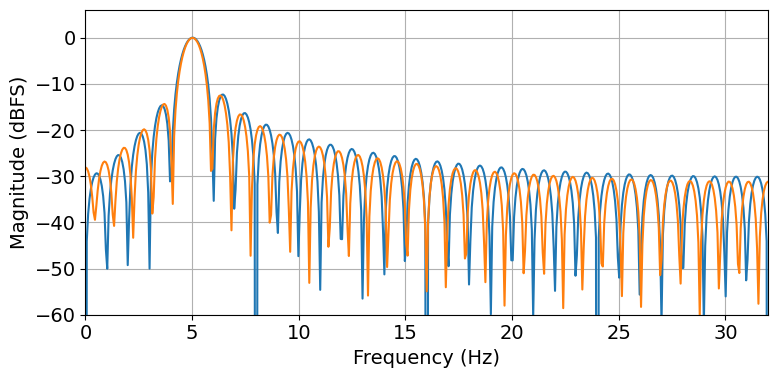

In [10]:
Fs = 64
f0 = 5
A = 1

fig, ax = plt.subplots(1,1, figsize=(8,4))

x, t = gen_cos(amp=A, freq=f0, Fs=Fs, dur=1)
X, f = dft(x, Fs, 1000)
plot_vs_freq(X, f, Fs, fmt='-', fig=(fig,ax))


x, t = gen_cos(amp=A, freq=f0, Fs=Fs, dur=1.1)
X, f = dft(x, Fs, 1000)
plot_vs_freq(X, f, Fs, fmt='-', fig=(fig,ax))


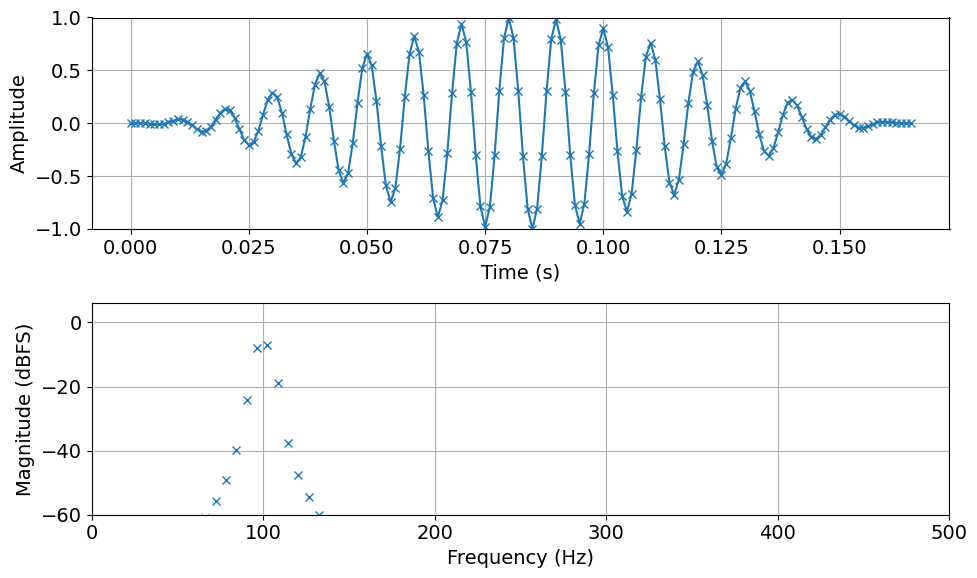

In [11]:
Fs = 1000
f = 100
dur = 1/6
fig, [ax1, ax2] = plt.subplots(2,1, figsize=(10,6))
x, t = gen_cos(amp=1, freq=f, Fs=Fs, dur=dur)

# windowing
w = scipy.signal.get_window('hann', len(x))
x = x * w

plot_vs_time(x, t, fmt='-x', fig=(fig,ax1))
X, f = dft(x, Fs)
plot_vs_freq(X, f, Fs, fmt='x', fig=(fig,ax2))


xp = np.tile(x,8)
samps = int(  (len(xp) ) * 8000 / Fs ) # the frequency f remains the same
signal = scipy.signal.resample(xp, samps)
ipd.display(ipd.Audio(signal, rate=8000))

import soundfile as sf
sf.write('resampled.wav', xp, 8000)


# As shown in Fig. 6.10, the elimination of discontinuities does change the signal: we have also introduced a low-frequency amplitude modulation to the looped signal.
# In this example, we have traded off transient discontinuities for a smoothly varying pulse, which can be more easily modeled by sinusoids.